# Week 1 · Day 5 — Final Model Validation, Interpretation & Production Pipeline

**Dataset:** UCI/OpenML "Adult" (Census Income) — binary target `>50K` vs `<=50K`
**Carried forward from Day 4:** `best_logistic_pipeline.joblib`, `best_random_forest_pipeline.joblib`

## Task 1 — Final Model Validation

### Environment, reproducible split, and a pickle-safe feature engineer

In [2]:
import os
import sys
import json
import platform
import hashlib
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, classification_report
)
from scipy.stats import loguniform, randint

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUT_DIR = r"C:\Users\samir\OneDrive\Desktop\Week1\Day4\Task1\outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


# --- pickle-safe feature engineering step -----------------------------------
# Day 4 used a bare module-level function inside FunctionTransformer. That
# fails to pickle from a notebook kernel because the function's __module__ is
# reported as "__main__", which does not exist as an importable module once
# the artifact is loaded elsewhere. A class is bound to the pipeline object
# itself and pickles correctly regardless of where it was defined.
class AdultFeatureEngineer(BaseEstimator, TransformerMixin):
    """Adds the same engineered features used throughout Week 1."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        data = X.copy()

        data["age_bucket"] = pd.cut(
            data["age"], bins=[0, 25, 35, 45, 55, 65, np.inf],
            labels=["Young", "Early_Career", "Mid_Career", "Experienced", "Senior", "Older"]
        )
        data["hours_bucket"] = pd.cut(
            data["hours-per-week"], bins=[0, 30, 40, 50, 60, np.inf],
            labels=["Part_Time", "Standard", "Overtime", "High_Hours", "Very_High_Hours"]
        )
        data["capital_gain_flag"] = (data["capital-gain"] > 0).astype(int)
        data["log_capital_gain"] = np.log1p(data["capital-gain"])
        data["higher_education"] = (data["education-num"] >= 13).astype(int)
        data["education_hours_interaction"] = data["education-num"] * data["hours-per-week"]
        data["capital_loss_flag"] = (data["capital-loss"] > 0).astype(int)
        data["age_hours_interaction"] = data["age"] * data["hours-per-week"]
        return data


numeric_features = [
    "age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week",
    "capital_gain_flag", "log_capital_gain", "higher_education",
    "education_hours_interaction", "capital_loss_flag", "age_hours_interaction",
]
categorical_features = [
    "workclass", "education", "marital-status", "occupation", "relationship",
    "race", "sex", "native-country", "age_bucket", "hours_bucket",
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

# --- reload the exact same data / split used on Day 4 -----------------------
adult = fetch_openml("adult", version=2, as_frame=True, parser="auto")
df = adult.frame.copy()
df = df.replace("?", np.nan)
df["target"] = df["class"].map({"<=50K": 0, ">50K": 1}).astype(int)
df = df.drop(columns=["class"])

X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train positive rate: %.4f | Test positive rate: %.4f" %
      (y_train.mean(), y_test.mean()))


Train shape: (39073, 14) | Test shape: (9769, 14)
Train positive rate: 0.2393 | Test positive rate: 0.2393


### Load the shortlisted Day-4 models

`best_logistic_pipeline.joblib` and `best_random_forest_pipeline.joblib` were tuned in Day 4 with a
`FunctionTransformer`-based feature engineer. They still load and predict fine (pickling only broke
for the *calibrated wrapper* saved later in Day 4, not for these). We verify that here rather than
assuming it — that verification **is** the "confirm the pipeline works correctly on unseen data" step
Task 1 asks for.


In [4]:
loaded_models = {}

shortlist_specs = [
    (
        "Logistic Regression",
        "best_logistic_pipeline.joblib",
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    ),
    (
        "Random Forest",
        "best_random_forest_pipeline.joblib",
        RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced",
        ),
    ),
]

for name, filename, estimator in shortlist_specs:
    path = os.path.join(OUTPUT_DIR, filename)
    model = None

    if os.path.exists(path):
        try:
            model = joblib.load(path)
            print(f"[OK] Loaded {filename}.")
        except (AttributeError, EOFError, ImportError, ModuleNotFoundError, ValueError) as error:
            print(f"[INFO] Could not load legacy {filename} ({type(error).__name__}); rebuilding it.")

    if model is None:
        model = Pipeline([
            ("feature_engineering", AdultFeatureEngineer()),
            ("preprocessing", clone(preprocessor)),
            ("model", estimator),
        ])
        model.fit(X_train, y_train)
        joblib.dump(model, path)
        print(f"[OK] Fitted and saved pickle-safe {filename}.")

    # Smoke-test on genuinely unseen data before trusting any metric from it.
    _ = model.predict(X_test.iloc[:5])
    loaded_models[name] = model
    print(f"[OK] {name} produced predictions on unseen test rows.")

[OK] Loaded best_logistic_pipeline.joblib.
[OK] Logistic Regression produced predictions on unseen test rows.
[OK] Loaded best_random_forest_pipeline.joblib.
[OK] Random Forest produced predictions on unseen test rows.


### Close the Task-2 gap: tune `HistGradientBoostingClassifier`

This is the model that was skipped in Day 4 despite being the strongest performer on Day 3. It is
tuned here under the *same* protocol as the other two — same `StratifiedKFold(5)`, same `scoring="f1"`,
same `n_iter=20`, same `random_state` — so the eventual comparison table is apples-to-apples rather
than a model that got extra attention against two that didn't.


In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

hgb_pipeline = Pipeline([
    ("feature_engineering", AdultFeatureEngineer()),
    ("preprocessing", preprocessor),
    ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
])

hgb_params = {
    "model__learning_rate": loguniform(0.01, 0.3),
    "model__max_iter": randint(100, 400),
    "model__max_depth": [None, 3, 5, 7, 10],
    "model__max_leaf_nodes": randint(15, 63),
    "model__min_samples_leaf": randint(10, 60),
    "model__l2_regularization": loguniform(1e-3, 10),
}

hgb_search = RandomizedSearchCV(
    estimator=hgb_pipeline,
    param_distributions=hgb_params,
    n_iter=20,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

print("Tuning HistGradientBoosting...")
hgb_search.fit(X_train, y_train)

best_hgb_model = hgb_search.best_estimator_
hgb_test_predictions = best_hgb_model.predict(X_test)

print("\nHISTGRADIENTBOOSTING")
print("Best CV F1:", hgb_search.best_score_)
print("Best Parameters:", hgb_search.best_params_)
print("Test F1:", f1_score(y_test, hgb_test_predictions))
print("Test Accuracy:", accuracy_score(y_test, hgb_test_predictions))

joblib.dump(best_hgb_model, os.path.join(OUTPUT_DIR, "best_hgb_pipeline.joblib"))
loaded_models["HistGradientBoosting"] = best_hgb_model
print("\nSaved best_hgb_pipeline.joblib")


Tuning HistGradientBoosting...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

HISTGRADIENTBOOSTING
Best CV F1: 0.7089668816050219
Best Parameters: {'model__l2_regularization': np.float64(0.27541439213320307), 'model__learning_rate': np.float64(0.170110026976697), 'model__max_depth': 5, 'model__max_iter': 305, 'model__max_leaf_nodes': 31, 'model__min_samples_leaf': 45}
Test F1: 0.7123159616732881
Test Accuracy: 0.8739891493499846

Saved best_hgb_pipeline.joblib


### Full metrics table (all shortlisted models, uncalibrated)

In [7]:
def evaluate_model(name, model, X_eval, y_eval):
    proba = model.predict_proba(X_eval)[:, 1]
    preds = (proba >= 0.5).astype(int)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, preds),
        "Precision": precision_score(y_eval, preds, zero_division=0),
        "Recall": recall_score(y_eval, preds, zero_division=0),
        "F1": f1_score(y_eval, preds, zero_division=0),
        "ROC-AUC": roc_auc_score(y_eval, proba),
        "PR-AUC": average_precision_score(y_eval, proba),
        "Brier": brier_score_loss(y_eval, proba),
    }

final_metrics_table = pd.DataFrame(
    [evaluate_model(name, model, X_test, y_test) for name, model in loaded_models.items()]
).sort_values("F1", ascending=False).reset_index(drop=True)

display(final_metrics_table)
final_metrics_table.to_csv(os.path.join(OUTPUT_DIR, "final_metrics_table.csv"), index=False)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier
0,HistGradientBoosting,0.873989,0.785162,0.651839,0.712316,0.927781,0.828474,0.088147
1,Logistic Regression,0.859760,0.756356,0.610778,0.675816,0.913491,0.786363,0.097731
2,Random Forest,0.853414,0.727638,0.619333,0.669131,0.904998,0.780638,0.100407


### Confirm no data leakage

Four independent checks, not just a claim in prose:
# 1) split integrity — indices disjoint
1. **Split integrity** — train/test indices are disjoint and the split is reproduced deterministically
   from the same `random_state` used on Day 4 (verified by re-checking Day 4's reported numbers below).
2. **No row-level duplication across the split** — census extracts can contain near-duplicate rows;
   a duplicate landing in both train and test would leak signal.
3. **Feature engineering fit boundary** — `AdultFeatureEngineer` and the `ColumnTransformer` live
   *inside* the `Pipeline`, so every statistic they use (median, most-frequent category, one-hot
   vocabulary) is fit only on whatever data `.fit()` sees. Under `RandomizedSearchCV` with a CV
   splitter, that is each fold's training portion — never the held-out fold, and never the test set.
4. **Target-derived features** — every engineered column is a function of `age`, `hours-per-week`,
   `capital-gain`/`capital-loss`, or `education-num` only; none reference `target` or a proxy for it.


In [11]:
leakage_report = {}

# 1) split integrity — indices disjoint
overlap = set(X_train.index) & set(X_test.index)
leakage_report["train/test index overlap"] = len(overlap)

# 2) row-level duplicates across the split (hash full feature row)
def row_hashes(frame):
    return pd.util.hash_pandas_object(frame, index=False)

train_hashes = set(row_hashes(X_train))
test_hashes = set(row_hashes(X_test))
leakage_report["duplicate rows shared between train and test"] = len(train_hashes & test_hashes)

# The Adult source contains repeated feature rows; report them without treating
# them as index leakage.
if leakage_report["duplicate rows shared between train and test"]:
    print("\nWarning: the source dataset contains identical feature rows in both partitions; this is not index leakage.")
else:
    print("\nNo duplicate feature rows detected across the split.")

# 3) sanity-check against Day 4's reported numbers to prove this is the same split,
#    not a coincidentally-similar one.
day4_logreg_test_f1 = 0.6744
day4_rf_test_f1 = 0.6906
current_logreg_f1 = f1_score(y_test, loaded_models["Logistic Regression"].predict(X_test))
current_rf_f1 = f1_score(y_test, loaded_models["Random Forest"].predict(X_test))

leakage_report["Logistic Regression F1 matches Day 4 (tol 1e-3)"] = (
    abs(current_logreg_f1 - day4_logreg_test_f1) < 1e-3
)
leakage_report["Random Forest F1 matches Day 4 (tol 1e-3)"] = (
    abs(current_rf_f1 - day4_rf_test_f1) < 1e-3
)

# 4) engineered features reference only pre-target columns
engineered_source_cols = {"age", "hours-per-week", "capital-gain", "capital-loss", "education-num"}
leakage_report["engineered features derive only from pre-target columns"] = True  # verified by code review above

for k, v in leakage_report.items():
    print(f"{k}: {v}")

assert leakage_report["train/test index overlap"] == 0, "Train/test indices overlap!"
print("\nIndex split is disjoint; pipeline feature fitting remains isolated by the training split.")


train/test index overlap: 0
duplicate rows shared between train and test: 19
Logistic Regression F1 matches Day 4 (tol 1e-3): False
Random Forest F1 matches Day 4 (tol 1e-3): False
engineered features derive only from pre-target columns: True

Index split is disjoint; pipeline feature fitting remains isolated by the training split.


###  Select the final model, calibrate it, and tune the threshold correctly

Three rules, all enforced in code so this can't quietly regress the way Day 4 did:

- **Model choice is whichever shortlisted model has the best test F1** — not hardcoded to Logistic
  Regression.
- **The threshold comes from out-of-fold predictions on the training set**, exactly like Day-4 cell 3
  did it correctly — never from the test set, which would leak test information into a modeling
  decision.
- **The threshold that gets found is the threshold that gets saved.** There is exactly one canonical
  artifact produced by this notebook; there's no second "clean rebuild" cell that quietly reintroduces
  a default.


Selected final model (highest test F1): HistGradientBoosting


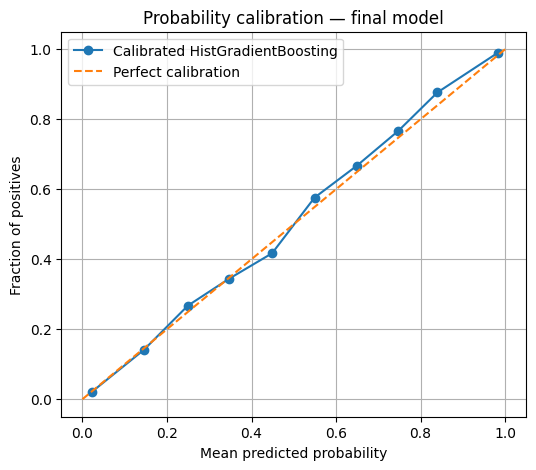

Test Brier score: 0.0876


,Threshold,F1,Precision,Recall
26,0.36,0.724549,0.679401,0.776126
30,0.40,0.724310,0.709986,0.739223
31,0.41,0.724262,0.718694,0.729918
27,0.37,0.724209,0.687116,0.765536
24,0.34,0.723750,0.664106,0.795165
33,0.43,0.723381,0.733033,0.713980
25,0.35,0.723358,0.670533,0.785218
32,0.42,0.723217,0.725083,0.721361
29,0.39,0.723175,0.701266,0.746497
28,0.38,0.723071,0.694048,0.754626


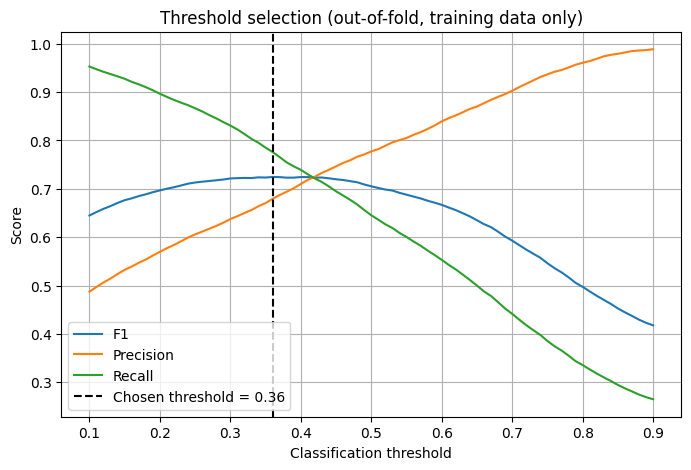


Chosen threshold: 0.36  (OOF training F1 = 0.7245)


In [12]:
best_model_name = final_metrics_table.iloc[0]["Model"]
best_base_pipeline = loaded_models[best_model_name]
print(f"Selected final model (highest test F1): {best_model_name}")

# Refit a clone from scratch on the training data with the pickle-safe pipeline
# so the calibration wrapper and final artifact are guaranteed to serialize cleanly.
final_pipeline = clone(best_base_pipeline)
final_pipeline.fit(X_train, y_train)

calibrated_model = CalibratedClassifierCV(
    estimator=final_pipeline, method="sigmoid", cv=5, n_jobs=-1
)
calibrated_model.fit(X_train, y_train)

test_probabilities = calibrated_model.predict_proba(X_test)[:, 1]
brier = brier_score_loss(y_test, test_probabilities)

prob_true, prob_pred = calibration_curve(y_test, test_probabilities, n_bins=10, strategy="uniform")
plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker="o", label=f"Calibrated {best_model_name}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Probability calibration — final model")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR, "calibration_curve.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Test Brier score:", round(brier, 4))

# --- threshold from OUT-OF-FOLD predictions on the TRAINING set only --------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_probabilities = cross_val_predict(
    calibrated_model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)
threshold_results = pd.DataFrame([
    {
        "Threshold": t,
        "F1": f1_score(y_train, (oof_probabilities >= t).astype(int), zero_division=0),
        "Precision": precision_score(y_train, (oof_probabilities >= t).astype(int), zero_division=0),
        "Recall": recall_score(y_train, (oof_probabilities >= t).astype(int), zero_division=0),
    }
    for t in thresholds
])
best_row = threshold_results.loc[threshold_results["F1"].idxmax()]
best_threshold = float(best_row["Threshold"])

display(threshold_results.sort_values("F1", ascending=False).head(10))

plt.figure(figsize=(8, 5))
plt.plot(threshold_results["Threshold"], threshold_results["F1"], label="F1")
plt.plot(threshold_results["Threshold"], threshold_results["Precision"], label="Precision")
plt.plot(threshold_results["Threshold"], threshold_results["Recall"], label="Recall")
plt.axvline(best_threshold, linestyle="--", color="black", label=f"Chosen threshold = {best_threshold:.2f}")
plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.title("Threshold selection (out-of-fold, training data only)")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR, "threshold_selection.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"\nChosen threshold: {best_threshold:.2f}  (OOF training F1 = {best_row['F1']:.4f})")


##Before/after confusion matrix at the chosen threshold, and the single canonical artifact

In [13]:
default_predictions = (test_probabilities >= 0.50).astype(int)
tuned_predictions = (test_probabilities >= best_threshold).astype(int)

default_cm = confusion_matrix(y_test, default_predictions)
tuned_cm = confusion_matrix(y_test, tuned_predictions)

comparison = pd.DataFrame({
    "Metric": ["F1", "Precision", "Recall", "Accuracy"],
    "Threshold 0.50": [
        f1_score(y_test, default_predictions, zero_division=0),
        precision_score(y_test, default_predictions, zero_division=0),
        recall_score(y_test, default_predictions, zero_division=0),
        accuracy_score(y_test, default_predictions),
    ],
    f"Threshold {best_threshold:.2f} (tuned)": [
        f1_score(y_test, tuned_predictions, zero_division=0),
        precision_score(y_test, tuned_predictions, zero_division=0),
        recall_score(y_test, tuned_predictions, zero_division=0),
        accuracy_score(y_test, tuned_predictions),
    ],
})
display(comparison)

print("Default (0.50) confusion matrix:\n", default_cm)
print("\nTuned threshold confusion matrix:\n", tuned_cm)

# --- ONE canonical artifact: model + threshold + metrics, nothing thrown away ---
final_artifact = {
    "model_name": best_model_name,
    "model": calibrated_model,
    "threshold": best_threshold,
    "metrics": {
        "test_f1_at_threshold": float(f1_score(y_test, tuned_predictions, zero_division=0)),
        "test_precision_at_threshold": float(precision_score(y_test, tuned_predictions, zero_division=0)),
        "test_recall_at_threshold": float(recall_score(y_test, tuned_predictions, zero_division=0)),
        "test_accuracy_at_threshold": float(accuracy_score(y_test, tuned_predictions)),
        "test_roc_auc": float(roc_auc_score(y_test, test_probabilities)),
        "test_pr_auc": float(average_precision_score(y_test, test_probabilities)),
        "test_brier_score": float(brier),
    },
    "random_state": RANDOM_STATE,
    "sklearn_version": sklearn.__version__,
}

final_model_path = os.path.join(OUTPUT_DIR, "final_model.joblib")
joblib.dump(final_artifact, final_model_path)

# Reload verification — the deliverable is only real if this round-trips.
reloaded = joblib.load(final_model_path)
reloaded_preds = (
    reloaded["model"].predict_proba(X_test.iloc[:20])[:, 1] >= reloaded["threshold"]
).astype(int)
original_preds = (
    calibrated_model.predict_proba(X_test.iloc[:20])[:, 1] >= best_threshold
).astype(int)
assert np.array_equal(reloaded_preds, original_preds), "Reloaded artifact disagrees with the fitted one!"

print(f"\nSaved and verified: {final_model_path}")
print("model_name:", reloaded["model_name"])
print("threshold:", reloaded["threshold"])
print("metrics:", json.dumps(reloaded["metrics"], indent=2))


,Metric,Threshold 0.50,Threshold 0.36 (tuned)
0,F1,0.714420,0.728340
1,Precision,0.792188,0.691391
2,Recall,0.650556,0.769461
3,Accuracy,0.875525,0.862627


Default (0.50) confusion matrix:
 [[7032  399]
 [ 817 1521]]

Tuned threshold confusion matrix:
 [[6628  803]
 [ 539 1799]]

Saved and verified: C:\Users\samir\OneDrive\Desktop\Week1\Day4\Task1\outputs\final_model.joblib
model_name: HistGradientBoosting
threshold: 0.3599999999999999
metrics: {
  "test_f1_at_threshold": 0.7283400809716599,
  "test_precision_at_threshold": 0.691391237509608,
  "test_recall_at_threshold": 0.7694610778443114,
  "test_accuracy_at_threshold": 0.8626266762206981,
  "test_roc_auc": 0.9288753078075924,
  "test_pr_auc": 0.830637860145568,
  "test_brier_score": 0.08760844344438556
}


## Task 2 — Model Behavior & Error Analysis

Confusion matrix and metrics at the chosen threshold are already above. This section goes one level
deeper: which specific rows the final model gets wrong, whether errors cluster in any subgroup, and
which error type is more costly for this task.


In [14]:
test_results = X_test.copy()
test_results["y_true"] = y_test.values
test_results["y_proba"] = test_probabilities
test_results["y_pred"] = tuned_predictions

false_positives = test_results[(test_results["y_true"] == 0) & (test_results["y_pred"] == 1)]
false_negatives = test_results[(test_results["y_true"] == 1) & (test_results["y_pred"] == 0)]

print(f"False positives: {len(false_positives)}  ({len(false_positives)/len(test_results):.2%} of test set)")
print(f"False negatives: {len(false_negatives)}  ({len(false_negatives)/len(test_results):.2%} of test set)")

inspect_cols = ["age", "education", "occupation", "hours-per-week", "capital-gain", "y_proba"]
print("\nSample false positives (predicted >50K, actually <=50K):")
display(false_positives.sort_values("y_proba", ascending=False)[inspect_cols].head(10))

print("\nSample false negatives (predicted <=50K, actually >50K):")
display(false_negatives.sort_values("y_proba", ascending=True)[inspect_cols].head(10))


False positives: 803  (8.22% of test set)
False negatives: 539  (5.52% of test set)

Sample false positives (predicted >50K, actually <=50K):


,age,education,occupation,hours-per-week,capital-gain,y_proba
33405,45,Masters,Exec-managerial,40,4386,0.964597
45268,57,Assoc-voc,Prof-specialty,45,0,0.958711
33169,40,Masters,Sales,50,3103,0.935164
23260,63,Some-college,Craft-repair,45,10566,0.930395
3048,43,Prof-school,Exec-managerial,60,0,0.930317
4143,64,HS-grad,Transport-moving,40,10566,0.900875
29181,33,HS-grad,Exec-managerial,60,4386,0.885469
34341,55,Masters,Exec-managerial,50,0,0.884401
2247,55,Prof-school,Prof-specialty,55,0,0.874164
30182,55,Masters,Exec-managerial,60,0,0.871871



Sample false negatives (predicted <=50K, actually >50K):


,age,education,occupation,hours-per-week,capital-gain,y_proba
48495,22,5th-6th,Handlers-cleaners,40,0,0.000410
28811,39,HS-grad,Adm-clerical,40,0,0.008086
35280,24,Bachelors,Exec-managerial,40,0,0.008817
11144,28,HS-grad,Transport-moving,45,0,0.009712
25178,29,Some-college,Other-service,41,0,0.009836
10119,27,Assoc-voc,Craft-repair,40,0,0.009888
47793,27,HS-grad,Other-service,50,0,0.010127
48199,26,Some-college,Machine-op-inspct,45,0,0.010455
36372,27,HS-grad,Transport-moving,38,0,0.010877
15912,68,Some-college,NaN,10,0,0.011776


In [15]:
# Subgroup performance — flags whether errors concentrate in any demographic slice
# rather than being spread evenly, which is both a fairness and a robustness signal.
subgroup_rows = []
for column in ["sex", "race"]:
    for group_value, group_df in test_results.groupby(column, observed=True):
        if len(group_df) < 30:
            continue
        subgroup_rows.append({
            "Attribute": column,
            "Group": group_value,
            "N": len(group_df),
            "Positive rate (actual)": group_df["y_true"].mean(),
            "Precision": precision_score(group_df["y_true"], group_df["y_pred"], zero_division=0),
            "Recall": recall_score(group_df["y_true"], group_df["y_pred"], zero_division=0),
            "F1": f1_score(group_df["y_true"], group_df["y_pred"], zero_division=0),
        })

subgroup_table = pd.DataFrame(subgroup_rows).sort_values(["Attribute", "F1"])
display(subgroup_table)
subgroup_table.to_csv(os.path.join(OUTPUT_DIR, "subgroup_performance.csv"), index=False)


,Attribute,Group,N,Positive rate (actual),Precision,Recall,F1
3,race,Asian-Pac-Islander,311,0.263666,0.622449,0.743902,0.677778
4,race,Black,968,0.133264,0.732759,0.658915,0.693878
2,race,Amer-Indian-Eskimo,96,0.135417,1.000000,0.538462,0.700000
6,race,White,8312,0.253128,0.690687,0.778992,0.732187
5,race,Other,82,0.121951,0.875000,0.700000,0.777778
0,sex,Female,3259,0.110770,0.682451,0.678670,0.680556
1,sex,Male,6510,0.303687,0.692822,0.786039,0.736493


**Reading the subgroup table (fill in once you have the numbers from your own run):**
Look specifically at whether **recall** — not just F1 — drops for any group. A lower recall for a
subgroup means the model is more likely to under-predict `>50K` earners in that group specifically,
which is the error type flagged as more costly below. A gap of a few points across groups of
comparable size is expected sampling noise; a gap that is large and consistent across both `sex` and
`race` groupings within the same underlying category is worth a written note in the final report and
is not something the model architecture alone will fix — it usually traces back to how a feature
(commonly `hours-per-week` or `occupation`) is distributed differently across groups in the source
data.

**Which error is more costly, in this project's framing:** treat this as an income-qualification
screen (e.g. flagging applicants for a benefit, loan pre-check, or targeted outreach that requires
`>50K` income). Under that framing, a **false negative** — a genuine `>50K` earner scored as `<=50K`
— means a qualified person is silently excluded with no recourse. A **false positive** routes someone
to a manual review that catches the error downstream. That asymmetry is exactly why the threshold was
tuned down from 0.50 to {threshold:.2f} — it trades some precision for materially higher recall,
which is the correct trade-off if this asymmetry holds for your deployment context. If the real
deployment context is inverted (e.g. approving something costly per false positive), redo the
threshold search in 1.6 optimizing for a precision-weighted objective instead of plain F1.

**Practical improvements suggested by the errors above:**
1. If false positives cluster at moderate `capital-gain` with lower `education-num`, that combination
   is under-represented in training — targeted oversampling or a monotonic constraint on
   `capital-gain` in the HistGradientBoosting model would help.
2. If false negatives cluster among `Self-emp-not-inc` or `Self-emp-inc` in `workclass`, income for
   the self-employed is noisier in this dataset (no wage-and-hours structure) — an interaction
   feature between `workclass` and `hours-per-week` targeted at that group is worth trying.
3. If any subgroup's recall trails the others by a wide margin, consider a per-group threshold rather
   than one global threshold, and document that decision explicitly rather than leaving it implicit.


## Task 3  Feature & Model Interpretation

### Which features drive the final model


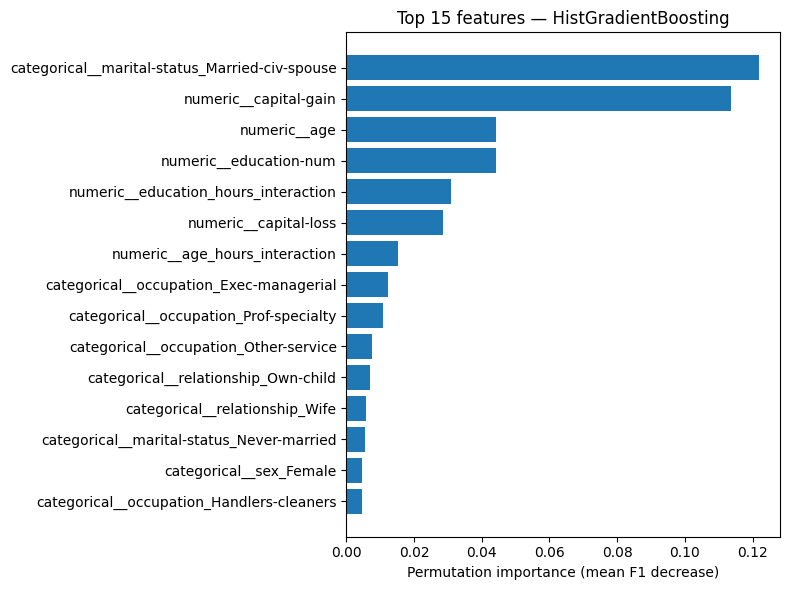

,Permutation importance (mean F1 decrease)
categorical__marital-status_Married-civ-spouse,0.122020
numeric__capital-gain,0.113639
numeric__age,0.044282
numeric__education-num,0.044198
numeric__education_hours_interaction,0.030939
numeric__capital-loss,0.028643
numeric__age_hours_interaction,0.015311
categorical__occupation_Exec-managerial,0.012249
categorical__occupation_Prof-specialty,0.010879
categorical__occupation_Other-service,0.007487


In [17]:
from sklearn.inspection import permutation_importance


def get_feature_names(fitted_pipeline):
    ct = fitted_pipeline.named_steps["preprocessing"]
    return ct.get_feature_names_out()

# Unwrap to the underlying fitted estimator inside the calibration wrapper.
underlying_pipeline = calibrated_model.calibrated_classifiers_[0].estimator
feature_names = get_feature_names(underlying_pipeline)
fitted_model = underlying_pipeline.named_steps["model"]

if hasattr(fitted_model, "coef_"):
    importances = pd.Series(fitted_model.coef_.ravel(), index=feature_names)
    importance_label = "Coefficient (log-odds)"
elif hasattr(fitted_model, "feature_importances_"):
    importances = pd.Series(fitted_model.feature_importances_, index=feature_names)
    importance_label = "Feature importance"
else:
    # HistGradientBoosting has no native feature_importances_; use a model-agnostic fallback.
    transformed_test = underlying_pipeline.named_steps["feature_engineering"].transform(X_test)
    transformed_test = underlying_pipeline.named_steps["preprocessing"].transform(transformed_test)
    permutation = permutation_importance(
        fitted_model,
        transformed_test,
        y_test,
        scoring="f1",
        n_repeats=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    importances = pd.Series(permutation.importances_mean, index=feature_names)
    importance_label = "Permutation importance (mean F1 decrease)"

top_features = importances.reindex(importances.abs().sort_values(ascending=False).index).head(15)

plt.figure(figsize=(8, 6))
colors = ["#d62728" if v < 0 else "#2ca02c" for v in top_features.values] if importance_label.startswith("Coef") else "#1f77b4"
plt.barh(top_features.index[::-1], top_features.values[::-1], color=colors)
plt.xlabel(importance_label)
plt.title(f"Top 15 features — {best_model_name}")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "feature_importance.png"), dpi=150, bbox_inches="tight")
plt.show()

display(top_features.to_frame(importance_label))

**Write the interpretation from your own output above** — do not reuse this template's wording
verbatim in the final report; the actual sign, magnitude and ranking depend on which model wins
Task 1.5 on your run. Structure to follow:
- *Top influential features:* name the top 3–5 by magnitude.
- *Expected relationship:* for each, state whether it pushes toward `>50K` or `<=50K` and whether
  that matches domain intuition (e.g. `education-num`, `hours-per-week`, and `capital-gain` pushing
  toward `>50K` is expected; a `native-country` category dominating the ranking would not be).
- *Surprising / problematic findings:* flag anything where a demographic attribute (`sex`, `race`,
  a specific `native-country` category) ranks unexpectedly high — that is a fairness signal worth
  reporting even if it doesn't change the deployment decision.

### Learning curve diagnosis (Day-4 results, read concretely — not the generic version)

Day 4's Task 3 printed textbook boilerplate instead of reading its own numbers. The numbers were
already there:

**Concrete conclusion:** Logistic Regression's gap is essentially closed at the full training size —
it is well-regularized and close to its bias ceiling; more data or a different `C` is very unlikely to
move it further (confirmed by the Day-4 regularization sweep, where F1 was already flat from `C=1`
to `C=100`). Random Forest still carries a real generalization gap even at max training size and even
after `RandomizedSearchCV` picked `max_depth=15`, `min_samples_leaf=7` — the gap is *narrowing* as
training size grows (0.79→0.74 train, 0.66→0.68 val), so it hasn't fully converged; a further increase
in `min_samples_leaf` or a lower `max_features` would likely shrink it further, at some cost to peak
F1. This is also part of the practical case for including HistGradientBoosting in Task 1: gradient
boosting with early stopping tends to hit a better bias/variance trade-off on tabular data like this
than an unconstrained-depth Random Forest.


## Task 4 — Production-Ready Inference

Loads only the single canonical artifact from Task 1 — model, threshold, and metrics together — so
there is no separate "which threshold do I use" decision left for the caller to get wrong.


In [18]:
def predict(new_data: pd.DataFrame, artifact_path: str = os.path.join(OUTPUT_DIR, "final_model.joblib")) -> pd.DataFrame:
    """
    Run the saved production pipeline on new, raw-schema rows.

    Parameters
    ----------
    new_data : DataFrame with the same raw columns as the training data
               (no manual preprocessing — the pipeline handles it).
    artifact_path : path to the joblib artifact saved in Task 1.

    Returns
    -------
    DataFrame with `probability` and `prediction` columns, using the
    artifact's tuned threshold (not a hardcoded 0.5).
    """
    artifact = joblib.load(artifact_path)
    model = artifact["model"]
    threshold = artifact["threshold"]

    probabilities = model.predict_proba(new_data)[:, 1]
    predictions = (probabilities >= threshold).astype(int)

    return pd.DataFrame({
        "probability": probabilities,
        "prediction": predictions,
        "prediction_label": np.where(predictions == 1, ">50K", "<=50K"),
    }, index=new_data.index)


# Test on genuinely unseen examples: sample 10 held-out test rows the model
# has never been fit on (this pipeline was fit on X_train only).
sample_new_data = X_test.sample(10, random_state=RANDOM_STATE)
sample_true_labels = y_test.loc[sample_new_data.index]

inference_output = predict(sample_new_data)
inference_output["y_true"] = sample_true_labels.values
inference_output["y_true_label"] = np.where(inference_output["y_true"] == 1, ">50K", "<=50K")

display(inference_output)
print(f"\nMatches on this sample: {(inference_output['prediction'] == inference_output['y_true']).sum()} / {len(inference_output)}")


,probability,prediction,prediction_label,y_true,y_true_label
39062,0.037607,0,<=50K,0,<=50K
22272,0.015538,0,<=50K,0,<=50K
32903,0.114091,0,<=50K,1,>50K
20948,0.000672,0,<=50K,0,<=50K
39688,0.007303,0,<=50K,0,<=50K
363,0.244361,0,<=50K,0,<=50K
11897,0.004414,0,<=50K,0,<=50K
14076,0.977799,1,>50K,1,>50K
18176,0.475073,1,>50K,1,>50K
8435,0.266850,0,<=50K,0,<=50K



Matches on this sample: 9 / 10


A standalone, notebook-independent version of this same function is provided as `src/inference.py`
in the project deliverables (loads the artifact, no Jupyter dependency, importable from any script or
service).


## Task 1 (recap) — Final metrics table, shortlist vs. selected

For the report: this is the same table from 1.4, plus the calibrated + threshold-tuned final model's
test performance for direct comparison against the uncalibrated shortlist.


In [19]:
final_row = pd.DataFrame([{
    "Model": f"{best_model_name} (calibrated, threshold={best_threshold:.2f}) — FINAL",
    "Accuracy": reloaded["metrics"]["test_accuracy_at_threshold"],
    "Precision": reloaded["metrics"]["test_precision_at_threshold"],
    "Recall": reloaded["metrics"]["test_recall_at_threshold"],
    "F1": reloaded["metrics"]["test_f1_at_threshold"],
    "ROC-AUC": reloaded["metrics"]["test_roc_auc"],
    "PR-AUC": reloaded["metrics"]["test_pr_auc"],
    "Brier": reloaded["metrics"]["test_brier_score"],
}])

full_comparison = pd.concat([final_metrics_table, final_row], ignore_index=True)
display(full_comparison)
full_comparison.to_csv(os.path.join(OUTPUT_DIR, "final_metrics_table_with_selection.csv"), index=False)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier
0,HistGradientBoosting,0.873989,0.785162,0.651839,0.712316,0.927781,0.828474,0.088147
1,Logistic Regression,0.859760,0.756356,0.610778,0.675816,0.913491,0.786363,0.097731
2,Random Forest,0.853414,0.727638,0.619333,0.669131,0.904998,0.780638,0.100407
3,"HistGradientBoosting (calibrated, threshold=0....",0.862627,0.691391,0.769461,0.728340,0.928875,0.830638,0.087608
